<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/or.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptrón OR

In [1]:
import numpy as np

# Tabla OR con bias como x0 = 1
# Cada fila: [x0, x1, x2]
X = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1],
])

y = np.array([0, 1, 1, 1])

def step(z):
    return 1 if z >= 0 else 0  # Heaviside clásica [web:17]

# Grid de búsqueda para w0, w1, w2
valores = np.linspace(-2, 2, 17)  # -2.0, -1.75, ..., 2.0 [web:4]

soluciones = []

for w0 in valores:
    for w1 in valores:
        for w2 in valores:
            w = np.array([w0, w1, w2])
            # salida del perceptrón: step(X @ w) para cada fila
            z = X @ w
            y_hat = np.array([step(zi) for zi in z])
            if np.array_equal(y_hat, y):
                soluciones.append(w)

print("Número de soluciones encontradas:", len(soluciones))
for w in soluciones:
    print(f"w = {w}  (w0=bias)")


Número de soluciones encontradas: 204
w = [-2.  2.  2.]  (w0=bias)
w = [-1.75  1.75  1.75]  (w0=bias)
w = [-1.75  1.75  2.  ]  (w0=bias)
w = [-1.75  2.    1.75]  (w0=bias)
w = [-1.75  2.    2.  ]  (w0=bias)
w = [-1.5  1.5  1.5]  (w0=bias)
w = [-1.5   1.5   1.75]  (w0=bias)
w = [-1.5  1.5  2. ]  (w0=bias)
w = [-1.5   1.75  1.5 ]  (w0=bias)
w = [-1.5   1.75  1.75]  (w0=bias)
w = [-1.5   1.75  2.  ]  (w0=bias)
w = [-1.5  2.   1.5]  (w0=bias)
w = [-1.5   2.    1.75]  (w0=bias)
w = [-1.5  2.   2. ]  (w0=bias)
w = [-1.25  1.25  1.25]  (w0=bias)
w = [-1.25  1.25  1.5 ]  (w0=bias)
w = [-1.25  1.25  1.75]  (w0=bias)
w = [-1.25  1.25  2.  ]  (w0=bias)
w = [-1.25  1.5   1.25]  (w0=bias)
w = [-1.25  1.5   1.5 ]  (w0=bias)
w = [-1.25  1.5   1.75]  (w0=bias)
w = [-1.25  1.5   2.  ]  (w0=bias)
w = [-1.25  1.75  1.25]  (w0=bias)
w = [-1.25  1.75  1.5 ]  (w0=bias)
w = [-1.25  1.75  1.75]  (w0=bias)
w = [-1.25  1.75  2.  ]  (w0=bias)
w = [-1.25  2.    1.25]  (w0=bias)
w = [-1.25  2.    1.5 ]  (w0=bias)


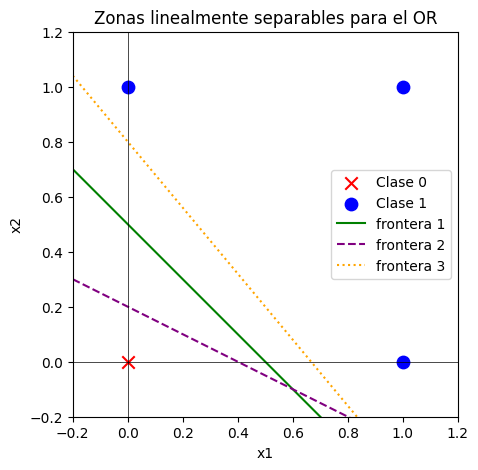

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Puntos de la tabla OR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])
y = np.array([0, 1, 1, 1])

# Dibujar puntos
plt.figure(figsize=(5, 5))
for (x1, x2), t in zip(X, y):
    if t == 0:
        plt.scatter(x1, x2, c="red", marker="x", s=80, label="Clase 0" if "Clase 0" not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(x1, x2, c="blue", marker="o", s=80, facecolors="none", label="Clase 1" if "Clase 1" not in plt.gca().get_legend_handles_labels()[1] else "")

# Algunas rectas que resuelven el OR:
# Recordando que el perceptrón decide con sign(w0 + w1*x1 + w2*x2)
# Dibujamos la frontera w0 + w1*x1 + w2*x2 = 0  ->  x2 = -(w0 + w1*x1)/w2

def plot_line(w0, w1, w2, **kwargs):
    xs = np.linspace(-0.2, 1.2, 100)
    # evitar dividir por 0
    if w2 == 0:
        return
    ys = -(w0 + w1 * xs) / w2
    plt.plot(xs, ys, **kwargs)

# Ejemplos de pesos que funcionan para OR
plot_line(-0.5, 1, 1, color="green", linestyle="-", label="frontera 1")
plot_line(-0.2, 0.5, 1, color="purple", linestyle="--", label="frontera 2")
plot_line(-0.8, 1.2, 1, color="orange", linestyle=":", label="frontera 3")

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Zonas linealmente separables para el OR")
plt.show()
